# 1. Environment Setup & Data Loading

## 1.1 Project configuration and global settings

In [1]:
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
def setup_data():
    org_path = "../"
    raw_path = f"{org_path}data/raw/"
    prc_path = f"{org_path}data/processed/"
    eda_path = f"{org_path}outputs/eda/"
    seed = 42

    print("변수 세팅 완료")
    return org_path, raw_path, prc_path, eda_path, seed

# 사용 예시 (반환값 9개)
org_path, raw_path, prc_path, eda_path, seed = setup_data()

변수 세팅 완료


In [3]:
def set_display_options():
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.float_format', lambda x: '%.3f' % x)
    print("디스플레이 옵션 설정 완료")
set_display_options()

디스플레이 옵션 설정 완료


## 1.2 Loading raw source files (CSV)

In [4]:
def load_multiple_csv_with_schema(
    base_path: str,
    filenames: List[str],
) -> Tuple[Dict[str, pd.DataFrame], List[str], List[str], List[str], List[str], List[str]]:
    """
    여러 CSV 파일을 한 번에 불러오되,
    사전에 정의한 key/cat/int/float/target 타입에 따라 dtype을 지정하여 로딩.

    Returns
    -------
    dataframes : dict[str, pd.DataFrame]
        각 파일명을 key, DataFrame을 value로 하는 딕셔너리
    key_cols : list[str]
    target_cols : list[str]
    cat_cols : list[str]
    int_cols : list[str]
    float_cols : list[str]
    """

    # 1) 변수 그룹 정의
    key_cols = [
        "user_id",
        "session_id",
    ]

    target_cols = [
        "label_repurchase",
    ]

    cat_cols = [
        "session_main_events",
        "session_browser",
        "session_traffic_source",
        "session_state",

        # 시간 start
        "session_start_hour",
        "session_start_weekday",
        "session_start_is_weekend",
        "session_start_day",
        "session_start_week",
        "session_start_month",
        "session_start_quarter",
        "session_start_year",

        # 시간 end
        "session_end_hour",
        "session_end_weekday",
        "session_end_is_weekend",
        "session_end_day",
        "session_end_week",
        "session_end_month",
        "session_end_quarter",
        "session_end_year",

        # 상품 / 사용자
        "product_category",
        "user_gender",
        "user_country",
    ]

    int_cols = [
        "session_event_count",
        "event_type_nunique",
        "user_age",
    ]

    float_cols = [
        "session_duration_hour",
        "total_price",
    ]

    num_cols = int_cols + float_cols

    # 2) dtype 매핑
    dtype_map: dict = {}
    dtype_map.update({col: "string" for col in key_cols})
    dtype_map.update({col: "string" for col in cat_cols})  # 나중에 category 변환
    dtype_map.update({col: "Int64" for col in int_cols + target_cols})
    dtype_map.update({col: "float" for col in float_cols})
    

    # 3) 여러 CSV 로딩
    base = Path(base_path)
    dataframes: Dict[str, pd.DataFrame] = {}

    for name in filenames:
        file_path = base / f"{name}.csv"

        if not file_path.exists():
            print(f"파일 없음: {file_path}")
            continue

        df = pd.read_csv(file_path, dtype=dtype_map)
        dataframes[name] = df
        print(f"{name}.csv 로드 완료 — shape={df.shape}")

    return dataframes, key_cols, target_cols, cat_cols, int_cols, float_cols, num_cols

In [5]:
file_list = [
    "train_df", "test_df"
]

# CSV 로드
dfs, key_cols, target_col, cat_cols, int_cols, float_cols, num_cols = load_multiple_csv_with_schema(
    base_path=prc_path,
    filenames=file_list
)
num_cols = int_cols+float_cols

train_df.csv 로드 완료 — shape=(62509, 31)
test_df.csv 로드 완료 — shape=(15628, 31)


In [6]:
# 변수 자동 생성
for name, df in dfs.items():
    globals()[name] = df
    print(f"테이블 생성 완료: {name} (shape={df.shape})")
del dfs

테이블 생성 완료: train_df (shape=(62509, 31))
테이블 생성 완료: test_df (shape=(15628, 31))


In [26]:
target_col

['label_repurchase']

# 2. 데이터 전처리

## 2.1 train / val / test set 분리

In [7]:
# 1) train_df
X = train_df.drop(target_col, axis=1)
y = train_df[target_col]

# 2) train / val 분리
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,      # 비율은 필요에 맞게 조정
    random_state=42,
    stratify=y          # 분류 문제라면 권장
)

# test_df
X_test = test_df.drop(target_col, axis=1)
y_test = test_df[target_col]


## 2.2 전처리 파이프라인

In [8]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [9]:
X_train_preprocessed = preprocess.fit_transform(X_train)
X_val_preprocessed = preprocess.transform(X_val)
X_test_preprocessed = preprocess.transform(X_test)

# 3. 모델링

In [10]:
print("==== train set ====")
print(y_train.value_counts(normalize=True))
print("==== val set ====")
print(y_val.value_counts(normalize=True))
print("==== test set ====")
print(y_test.value_counts(normalize=True))

==== train set ====
label_repurchase
1                  0.563
0                  0.437
Name: proportion, dtype: float64
==== val set ====
label_repurchase
1                  0.563
0                  0.437
Name: proportion, dtype: float64
==== test set ====
label_repurchase
1                  0.563
0                  0.437
Name: proportion, dtype: float64


## 3.1 SVM

In [11]:
# One-Hot 인코딩으로 차원이 커질 수 있어서, RBF SVC보다는 LinearSVC를 우선 사용
svm_clf = LinearSVC(random_state=42)

# 2) 학습
svm_clf.fit(X_train_preprocessed, y_train)

# 3) 검증 성능 확인 (val set)
y_val_pred_svm = svm_clf.predict(X_val_preprocessed)

c:\Users\Owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [12]:
print("=== SVM (LinearSVC) - Validation ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred_svm))
print(classification_report(y_val, y_val_pred_svm))

=== SVM (LinearSVC) - Validation ===
Accuracy: 0.7421212605983043
              precision    recall  f1-score   support

         0.0       0.65      0.87      0.75      5469
         1.0       0.87      0.64      0.74      7033

    accuracy                           0.74     12502
   macro avg       0.76      0.76      0.74     12502
weighted avg       0.77      0.74      0.74     12502



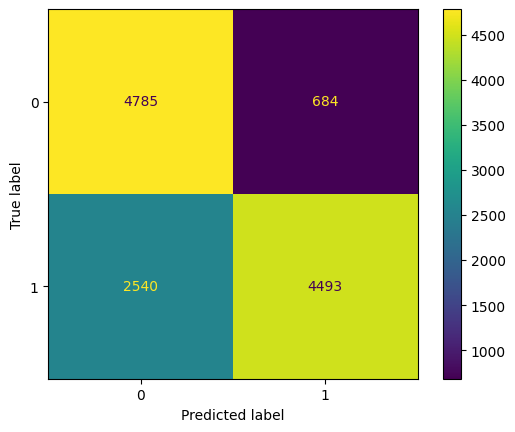

In [13]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_svm)

## 3.2 Logistic Regression

In [14]:
# 1) 모델 정의
log_clf = LogisticRegression(
    max_iter=1000,   # 수렴 보장용
    n_jobs=-1        # CPU 병렬 처리
)

# 2) 학습
log_clf.fit(X_train_preprocessed, y_train)

# 3) 검증 성능 확인 (val set)
y_val_pred_log = log_clf.predict(X_val_preprocessed)

c:\Users\Owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [15]:
print("=== Logistic Regression - Validation ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred_log))
print(classification_report(y_val, y_val_pred_log))

=== Logistic Regression - Validation ===
Accuracy: 0.7418812989921613
              precision    recall  f1-score   support

         0.0       0.65      0.87      0.75      5469
         1.0       0.87      0.64      0.74      7033

    accuracy                           0.74     12502
   macro avg       0.76      0.76      0.74     12502
weighted avg       0.77      0.74      0.74     12502



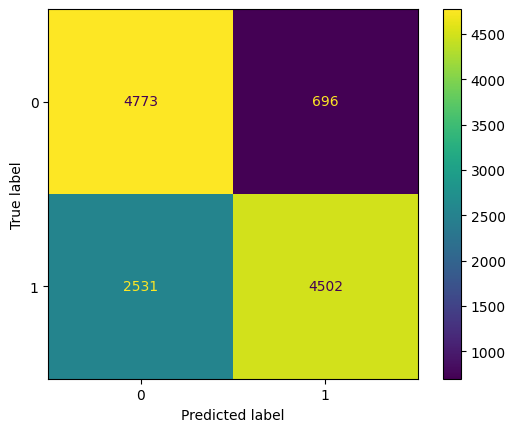

In [16]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_log)

# 4. 결과 분석

## 4.1 Learning Curve

In [17]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', label="Train F1")
    plt.plot(train_sizes, val_mean, 'o-', label="Validation F1")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

    plt.title(title)
    plt.xlabel("Training Size")
    plt.ylabel("F1 Score")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

**SVM Learning Curve**

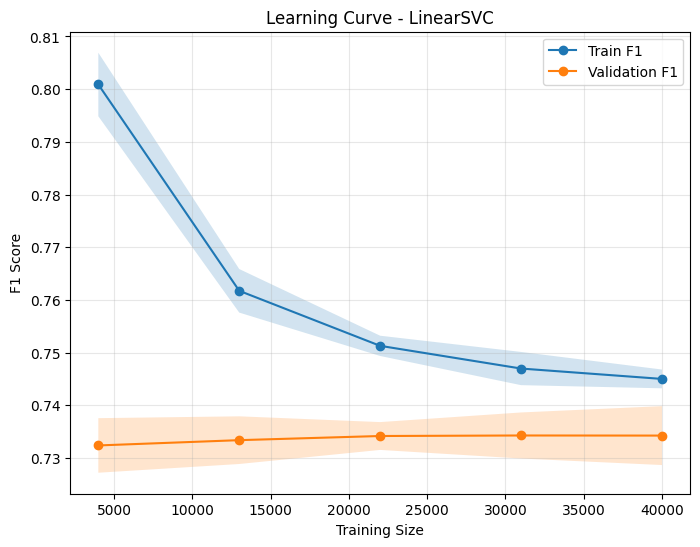

In [18]:
svm_model = LinearSVC(random_state=42)
plot_learning_curve(svm_model, X_train_preprocessed, y_train, "Learning Curve - LinearSVC")


**Logistic Regression Learning Curve**

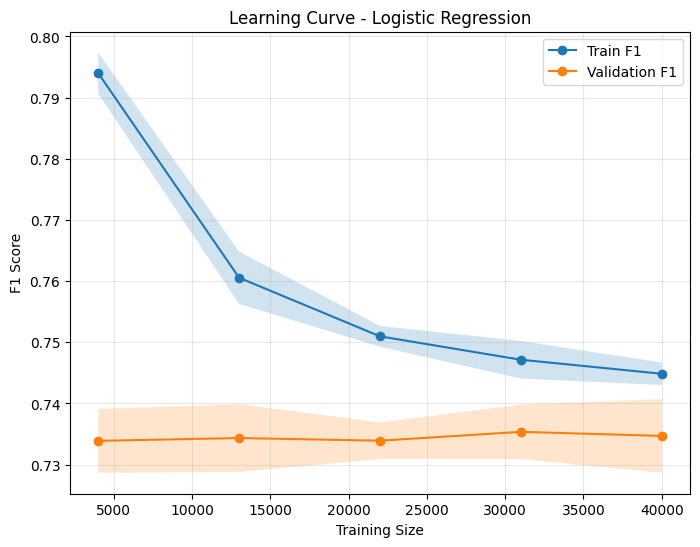

In [19]:
log_model = LogisticRegression(
    max_iter=1000,   # 수렴 보장용
    n_jobs=-1        # CPU 병렬 처리
)

plot_learning_curve(log_model, X_train_preprocessed, y_train, "Learning Curve - Logistic Regression")

**[결론]**
1. 학습 곡선 해석  
    - train, val 둘 다 0.7대에서 평탄하게 수렴 → 이 피처+모델 조합의 성능 상한이 0.7대 근처
    - 심각한 언더&오버피팅은 아님 → 데이터만 더 늘려서 해결될 문제는 아닐 가능성이 큼
    - 클래스 비율 0.57:0.43 → 불균형 영향은 “보조 요인 수준

2. 수행 우선 순위
    - 1순위: 피처 엔지니어링
      - 도메인 기반 새 변수 추가, 비선형 변환, 상호작용 피처 등으로 정보량 자체를 키우기
    - 2순위: 모델&하이퍼파라미터 조정
      - SVM&로지스틱에서 C, 커널, 특성 스케일링, 규제 강도 등으로 복잡도 조절
    - 3순위: 클래스 비율 관련 조정
      - class_weight, 샘플링은 해볼 가치는 있으나 성능 ceiling을 깨는 메인 수단은 아님

## 4.2 변수 중요도

In [20]:
# 1) 숫자형
num_feature_names = num_cols

# 2) 범주형 (OneHotEncoder categories)
cat_feature_names = preprocess.named_transformers_['cat']\
                       .get_feature_names_out(cat_cols)

# 3) 전체 feature 이름
all_feature_names = np.concatenate([num_feature_names, cat_feature_names])

**SVM**

In [21]:
svm_coefs = svm_clf.coef_[0]

svm_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "coef": svm_coefs,
    "abs_coef": np.abs(svm_coefs)
}).sort_values("abs_coef", ascending=False)

# 상위 20개
svm_importance_df.head(20)

,feature,coef,abs_coef
1,event_type_nunique,-1.901,1.901
108,session_state_Ibaraki,1.116,1.116
3,session_duration_hour,0.965,0.965
128,session_state_Kochi,0.939,0.939
234,session_state_Wakayama,0.935,0.935
238,session_state_West Virginia,-0.828,0.828
151,session_state_Nagano,-0.794,0.794
84,session_state_Gifu,-0.771,0.771
173,session_state_Okayama,0.741,0.741
213,session_state_Shimane,-0.732,0.732


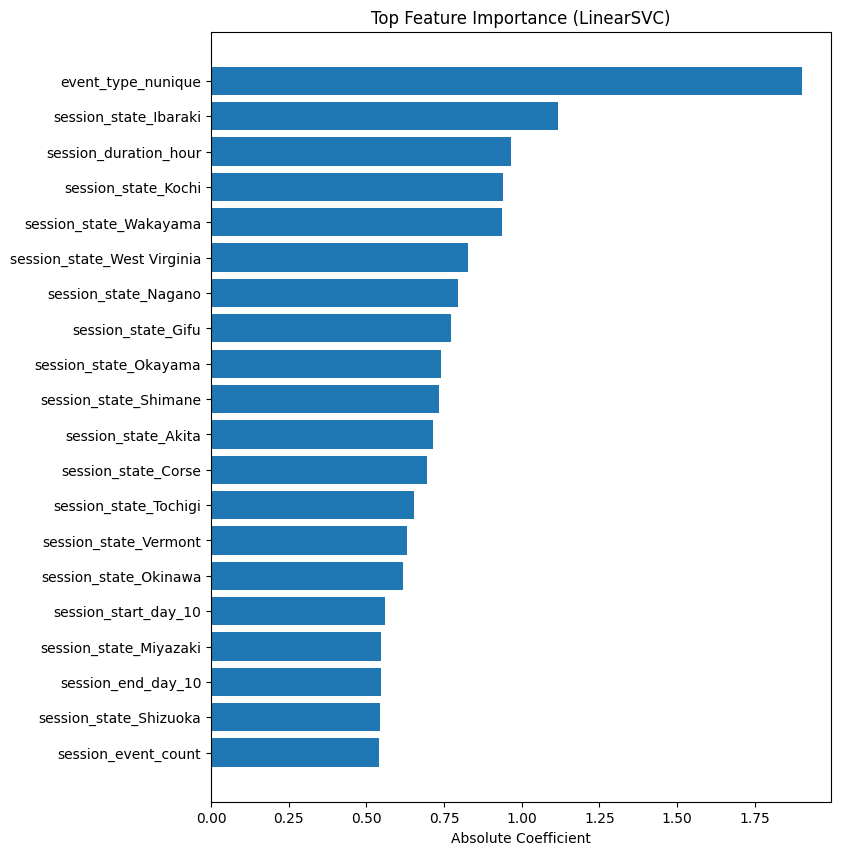

In [22]:
top_n = 20
top_svm = svm_importance_df.head(top_n).sort_values("abs_coef")

plt.figure(figsize=(8, 10))
plt.barh(top_svm["feature"], top_svm["abs_coef"])
plt.title("Top Feature Importance (LinearSVC)")
plt.xlabel("Absolute Coefficient")
plt.show()

**Logistic Regression**

In [25]:
# Logistic Regression 계수 기반 중요도

coefs = log_clf.coef_[0]  # shape: (n_features,)
coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

# 상위 20개
svm_importance_df.head(20)

,feature,coef,abs_coef
1,event_type_nunique,-1.901,1.901
108,session_state_Ibaraki,1.116,1.116
3,session_duration_hour,0.965,0.965
128,session_state_Kochi,0.939,0.939
234,session_state_Wakayama,0.935,0.935
238,session_state_West Virginia,-0.828,0.828
151,session_state_Nagano,-0.794,0.794
84,session_state_Gifu,-0.771,0.771
173,session_state_Okayama,0.741,0.741
213,session_state_Shimane,-0.732,0.732


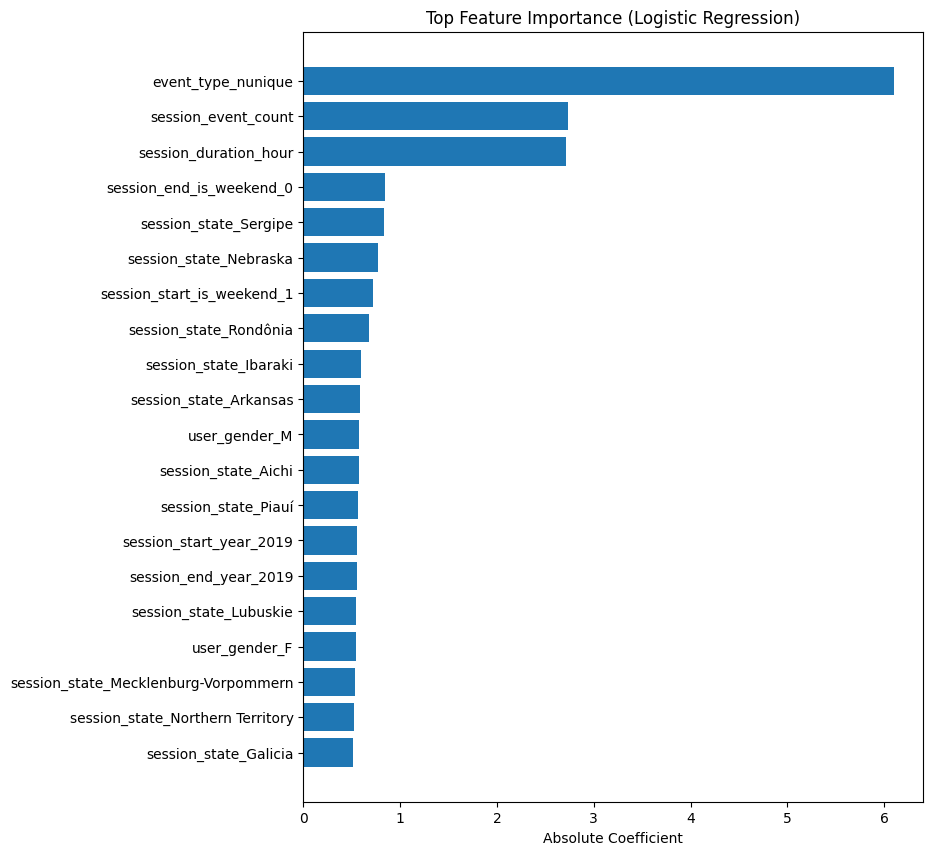

In [24]:
top_n = 20
top_features = coef_df.head(top_n).sort_values("abs_coef")

plt.figure(figsize=(8, 10))
plt.barh(top_features["feature"], top_features["abs_coef"])
plt.title("Top Feature Importance (Logistic Regression)")
plt.xlabel("Absolute Coefficient")
plt.show()